# Завдання 2 — варіант 8

Кольорові точки — навчальні (3 класи), чорні — тестові.

- **2.1** — класифікація за геометричною відстанню (L2) до центра мас кожного класу.
- **2.2** — проекція на пряму через центри мас; пряму обираємо за **сумою відстаней між крайніми точками** при проектуванні кожної навчальної множини; клас — за найближчим центроїдом у 1D.

In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")

## Вхідні дані (варіант 8)

In [2]:
CLASS_SPECS = {
    "Червоний": {"color": "tab:red", "points": np.array([[0, 6], [1, 8], [1, 6], [1, 4]], dtype=float)},
    "Зелений": {"color": "tab:green", "points": np.array([[5, 7], [6, 4], [3, 5], [4, 3]], dtype=float)},
    "Синій": {"color": "tab:blue", "points": np.array([[7, 3], [8, 0], [6, 2], [5, 1]], dtype=float)},
}

TEST_POINTS = np.array([[3, 7], [7, 5], [2, 3], [3, 1]], dtype=float)
CLASS_NAMES = list(CLASS_SPECS.keys())
train = {name: CLASS_SPECS[name]["points"] for name in CLASS_NAMES}

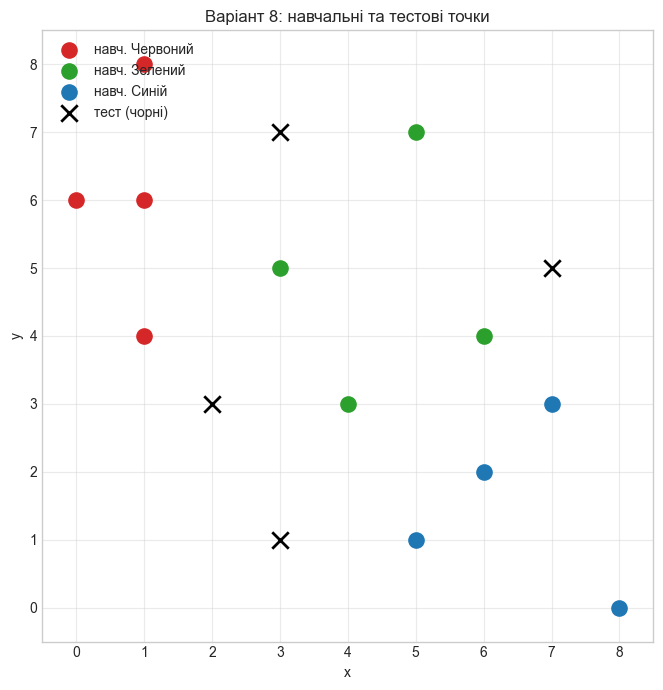

In [3]:
fig, ax = plt.subplots(figsize=(7, 7))
for name in CLASS_NAMES:
    pts = train[name]
    ax.scatter(pts[:, 0], pts[:, 1], c=CLASS_SPECS[name]["color"], s=120, label=f"навч. {name}", zorder=3)
ax.scatter(TEST_POINTS[:, 0], TEST_POINTS[:, 1], c="black", s=140, marker="x", linewidths=2, label="тест (чорні)", zorder=4)
ax.set_xlim(-0.5, 8.5)
ax.set_ylim(-0.5, 8.5)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Варіант 8: навчальні та тестові точки")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Центри мас

In [4]:
def centroids_by_class(class_points):
    return {name: pts.mean(axis=0) for name, pts in class_points.items()}


centroids = centroids_by_class(train)
print("Центри мас:")
for name in CLASS_NAMES:
    c = centroids[name]
    print(f"  {name}: ({c[0]:.4f}, {c[1]:.4f})")

Центри мас:
  Червоний: (0.7500, 6.0000)
  Зелений: (4.5000, 4.7500)
  Синій: (6.5000, 1.5000)


## Візуалізація: точки та центри мас

/var/folders/tt/_3ywz8k966s1ps_dnfnpgfy40000gn/T/ipykernel_76013/2476529532.py:40: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/user/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


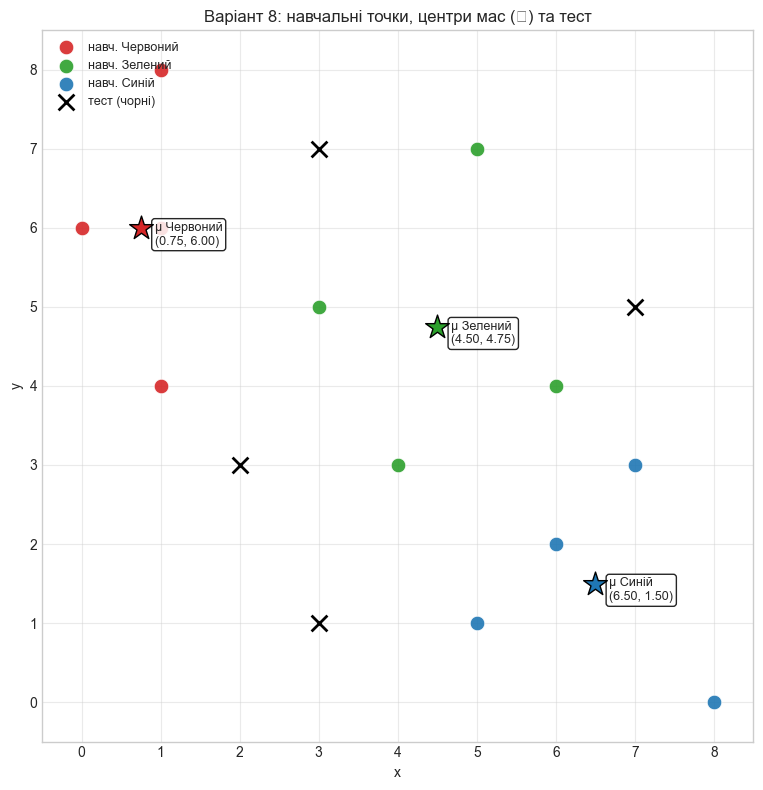

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))

for name in CLASS_NAMES:
    pts = train[name]
    c = centroids[name]
    ax.scatter(
        pts[:, 0], pts[:, 1],
        c=CLASS_SPECS[name]["color"], s=110, alpha=0.9,
        edgecolors="white", linewidths=0.6, zorder=3,
        label=f"навч. {name}",
    )
    ax.scatter(
        c[0], c[1],
        c=CLASS_SPECS[name]["color"], s=320, marker="*",
        edgecolors="black", linewidths=1.0, zorder=5,
    )
    ax.annotate(
        f"μ {name}\n({c[0]:.2f}, {c[1]:.2f})",
        (c[0], c[1]),
        textcoords="offset points",
        xytext=(10, -12),
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.85),
    )

ax.scatter(
    TEST_POINTS[:, 0], TEST_POINTS[:, 1],
    c="black", s=130, marker="x", linewidths=2,
    label="тест (чорні)", zorder=4,
)

ax.set_xlim(-0.5, 8.5)
ax.set_ylim(-0.5, 8.5)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Варіант 8: навчальні точки, центри мас (★) та тест")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 2.1 — відстань до центра мас (L2)

In [6]:
def pairwise_distances(point, centroids_dict):
    names = list(centroids_dict.keys())
    centers = np.array([centroids_dict[n] for n in names])
    diffs = centers - point
    d_l2 = np.linalg.norm(diffs, axis=1)
    d_l1 = np.sum(np.abs(diffs), axis=1)
    return names, d_l2, d_l1


def classify_l2(point, centroids_dict):
    names, d_l2, _ = pairwise_distances(point, centroids_dict)
    return names[int(np.argmin(d_l2))], d_l2


print("2.1 — класифікація чорних точок (L2 до центроїдів)")
print(f"{'точка':>12} | {'d(Ч)':>8} {'d(З)':>8} {'d(С)':>8} | клас")
print("-" * 52)
preds_21 = []
for i, p in enumerate(TEST_POINTS, start=1):
    names, d_l2, _ = pairwise_distances(p, centroids)
    pred = names[int(np.argmin(d_l2))]
    preds_21.append(pred)
    d = {n: d_l2[j] for j, n in enumerate(names)}
    print(f"({p[0]:g},{p[1]:g}){'':>4} | {d['Червоний']:8.4f} {d['Зелений']:8.4f} {d['Синій']:8.4f} | {pred}")

2.1 — класифікація чорних точок (L2 до центроїдів)
       точка |     d(Ч)     d(З)     d(С) | клас
----------------------------------------------------
(3,7)     |   2.4622   2.7042   6.5192 | Червоний
(7,5)     |   6.3295   2.5125   3.5355 | Зелений
(2,3)     |   3.2500   3.0516   4.7434 | Зелений
(3,1)     |   5.4829   4.0389   3.5355 | Синій


## 2.2 — проекція на пряму через центри мас

Кандидатні прямі: через пари центроїдів. Критерій вибору прямої — **максимізувати** суму розмахів проекцій по кожному класу:

$$S(L) = \sum_{k=1}^{3} \bigl(\max_{x\in C_k} t(x) - \min_{x\in C_k} t(x)\bigr),$$

де $t(x) = (x - o)^\top u$ — координата проекції на одиничний напрям $u$ прямої $L$.

In [7]:
pairs = list(itertools.combinations(CLASS_NAMES, 2))


def make_line(a, b, centroids_dict):
    ca, cb = centroids_dict[a], centroids_dict[b]
    d = cb - ca
    norm = np.linalg.norm(d)
    if norm < 1e-12:
        raise ValueError(f"Центроїди {a} та {b} збігаються")
    u = d / norm
    return {"a": a, "b": b, "origin": ca, "u": u}


def proj(points, line):
    pts = np.atleast_2d(points)
    return (pts - line["origin"]) @ line["u"]


def extreme_span_sum(line, class_points):
    """Сума відстаней між крайніми проекціями по кожній навчальній множині."""
    total = 0.0
    spans = {}
    for name, pts in class_points.items():
        t = proj(pts, line)
        span = float(t.max() - t.min())
        spans[name] = span
        total += span
    return total, spans


lines = {f"{a}–{b}": make_line(a, b, centroids) for a, b in pairs}

print("Критерій S(L) = сума розмахів проекцій по класах (обираємо max):")
stats = {}
for lname, line in lines.items():
    total, spans = extreme_span_sum(line, train)
    stats[lname] = {"sum_extreme": total, "spans": spans, "line": line}
    span_str = ", ".join(f"{k}: {v:.4f}" for k, v in spans.items())
    print(f"  {lname:20}  S = {total:.4f}  ({span_str})")

best_name = max(stats, key=lambda k: stats[k]["sum_extreme"])
best_line = stats[best_name]["line"]
print(f"\nОбрана пряма: {best_name}, S = {stats[best_name]['sum_extreme']:.4f}")

Критерій S(L) = сума розмахів проекцій по класах (обираємо max):
  Червоний–Зелений      S = 7.9057  (Червоний: 1.5811, Зелений: 3.1623, Синій: 3.1623)
  Червоний–Синій        S = 8.4229  (Червоний: 2.4652, Зелений: 2.9788, Синій: 2.9788)
  Зелений–Синій         S = 9.5648  (Червоний: 3.4066, Зелений: 3.0791, Синій: 3.0791)

Обрана пряма: Зелений–Синій, S = 9.5648


In [8]:
cent_proj = {name: float(proj(centroids[name][None, :], best_line)[0]) for name in CLASS_NAMES}
print("Проекції центроїдів на обрану пряму:")
for name in CLASS_NAMES:
    print(f"  {name}: t = {cent_proj[name]:.4f}")


def classify_proj(point, centroids_dict, line):
    t = float(proj(point[None, :], line)[0])
    pred = min(centroids_dict.keys(), key=lambda cn: abs(t - cent_proj[cn]))
    return pred, t


print("\n2.2 — класифікація чорних точок (проекція)")
print(f"{'точка':>12} | {'t':>8} | {'|t-tц| по класах':<30} | клас")
print("-" * 70)
preds_22 = []
for p in TEST_POINTS:
    pred, t = classify_proj(p, centroids, best_line)
    preds_22.append(pred)
    gaps = ", ".join(f"{n[:3]}:{abs(t - cent_proj[n]):.3f}" for n in CLASS_NAMES)
    print(f"({p[0]:g},{p[1]:g}){'':>4} | {t:8.4f} | {gaps:<30} | {pred}")

Проекції центроїдів на обрану пряму:
  Червоний: t = -3.0299
  Зелений: t = 0.0000
  Синій: t = 3.8161

2.2 — класифікація чорних точок (проекція)
       точка |        t | |t-tц| по класах               | клас
----------------------------------------------------------------------
(3,7)     |  -2.7024 | Чер:0.328, Зел:2.702, Син:6.518 | Червоний
(7,5)     |   1.0973 | Чер:4.127, Зел:1.097, Син:2.719 | Зелений
(2,3)     |   0.1802 | Чер:3.210, Зел:0.180, Син:3.636 | Зелений
(3,1)     |   2.4076 | Чер:5.438, Зел:2.408, Син:1.409 | Синій


### Усі кандидатні прямі та проекції \(t\)


Пряма Червоний–Зелений  |  o = μ_Чер = (0.75, 6.00)
  u = (0.9487, -0.3162)  |  S(L) = 7.9057
  Розмахи: Чер=1.5811, Зел=3.1623, Син=3.1623
точка          клас                t
--------------------------------------
(0,6)       Червоний      -0.7115
(1,8)       Червоний      -0.3953
(1,6)       Червоний       0.2372
(1,4)       Червоний       0.8696
(5,7)       Зелений        3.7157
(6,4)       Зелений        5.6130
(3,5)       Зелений        2.4508
(4,3)       Зелений        4.0319
(7,3)       Синій          6.8780
(8,0)       Синій          8.7753
(6,2)       Синій          6.2455
(5,1)       Синій          5.6130
μ Червоний центроїд       0.0000
μ Зелений  центроїд       3.9528
μ Синій    центроїд       6.8780
(3,7)       тест           1.8183
(7,5)       тест           6.2455
(2,3)       тест           2.1345
(3,1)       тест           3.7157

Пряма Червоний–Синій  |  o = μ_Чер = (0.75, 6.00)
  u = (0.7875, -0.6163)  |  S(L) = 8.4229
  Розмахи: Чер=2.4652, Зел=2.9788, Син=2.9788
т

/var/folders/tt/_3ywz8k966s1ps_dnfnpgfy40000gn/T/ipykernel_76013/3122440450.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/tt/_3ywz8k966s1ps_dnfnpgfy40000gn/T/ipykernel_76013/3122440450.py:100: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()


/Users/user/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


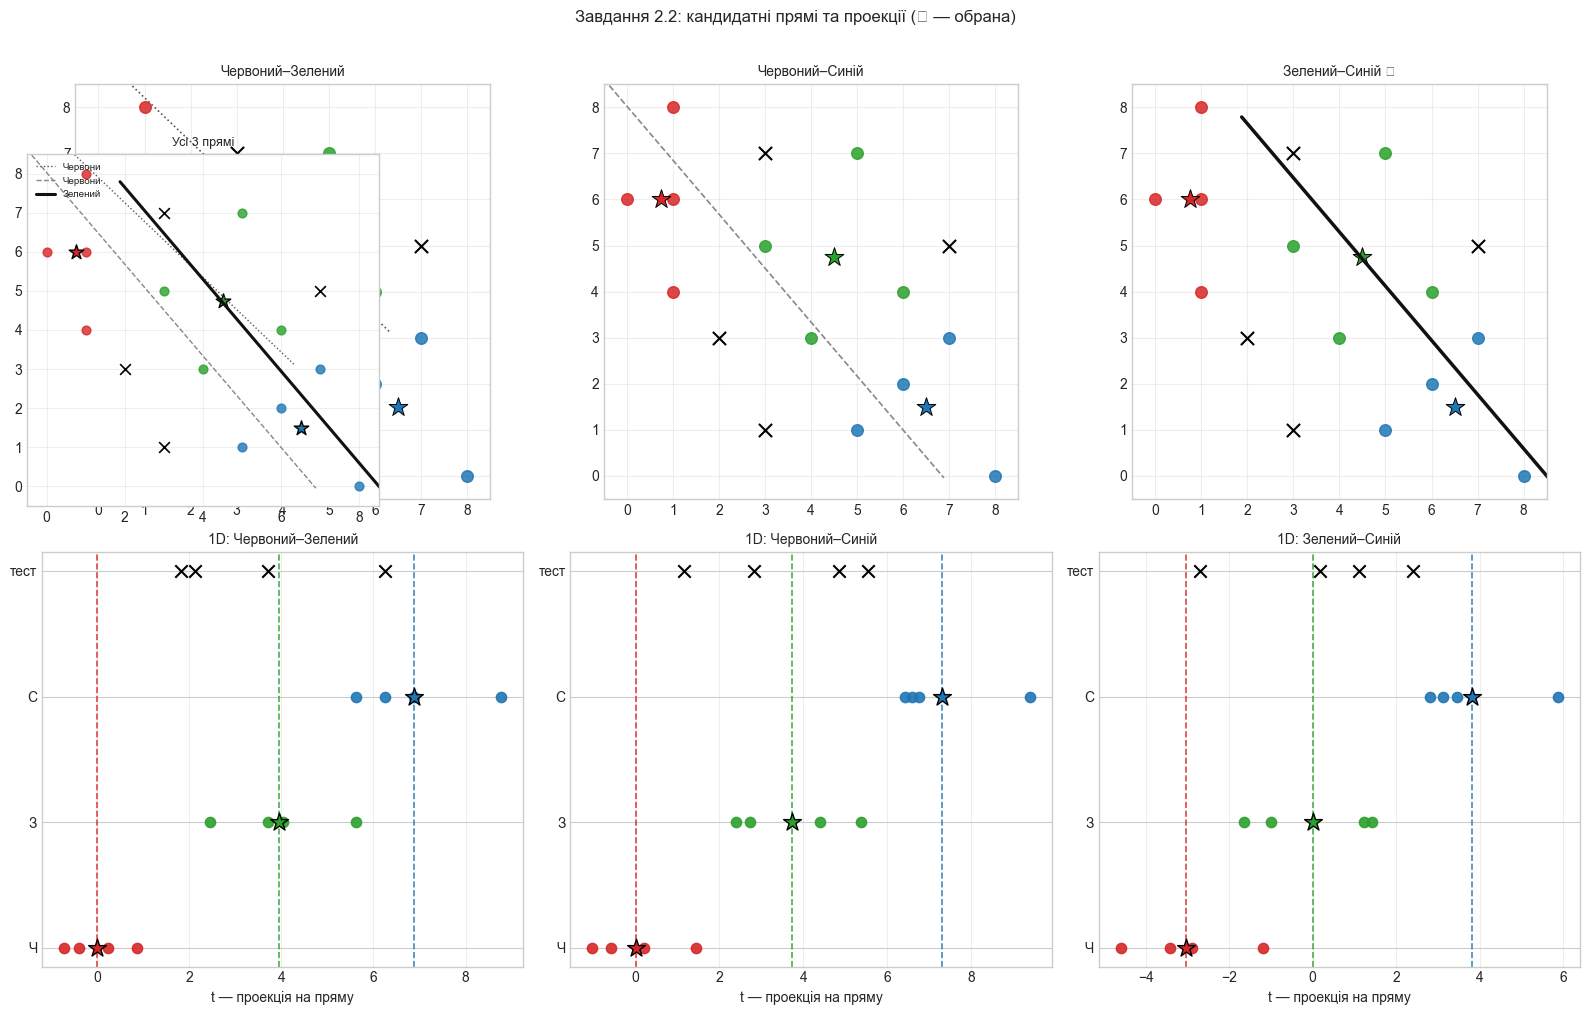

In [9]:
def line_segment_2d(line, t_min, t_max, pad=0.4):
    o, u = line["origin"], line["u"]
    t0, t1 = t_min - pad, t_max + pad
    return np.column_stack([o + t0 * u, o + t1 * u])


def print_proj_table(line_name, line):
    total, spans = extreme_span_sum(line, train)
    print(f"\n{'=' * 72}")
    print(f"Пряма {line_name}  |  o = μ_{line['a'][:3]} = ({line['origin'][0]:.2f}, {line['origin'][1]:.2f})")
    print(f"  u = ({line['u'][0]:.4f}, {line['u'][1]:.4f})  |  S(L) = {total:.4f}")
    print(f"  Розмахи: " + ", ".join(f"{k[:3]}={spans[k]:.4f}" for k in CLASS_NAMES))
    print(f"{'точка':<14} {'клас':<10} {'t':>10}")
    print("-" * 38)
    for cname in CLASS_NAMES:
        for i, p in enumerate(train[cname], start=1):
            t = float(proj(p[None, :], line)[0])
            print(f"({p[0]:g},{p[1]:g}){'':<6} {cname:<10} {t:10.4f}")
    for cname in CLASS_NAMES:
        t = float(proj(centroids[cname][None, :], line)[0])
        print(f"μ {cname:<8} {'центроїд':<10} {t:10.4f}")
    for p in TEST_POINTS:
        t = float(proj(p[None, :], line)[0])
        print(f"({p[0]:g},{p[1]:g}){'':<6} {'тест':<10} {t:10.4f}")


for lname in lines:
    print_proj_table(lname, lines[lname])

# --- Візуалізація: 3 прямі на площині + 1D-проекції ---
line_colors = {"Червоний–Зелений": "#555555", "Червоний–Синій": "#888888", "Зелений–Синій": "#111111"}
line_styles = {"Червоний–Зелений": ":", "Червоний–Синій": "--", "Зелений–Синій": "-"}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Верхній ряд: 2D — точки + одна пряма в кожній панелі
for ax, lname in zip(axes[0], lines.keys()):
    line = lines[lname]
    for cname in CLASS_NAMES:
        pts = train[cname]
        ax.scatter(pts[:, 0], pts[:, 1], c=CLASS_SPECS[cname]["color"], s=70, alpha=0.85)
        c = centroids[cname]
        ax.scatter(c[0], c[1], c=CLASS_SPECS[cname]["color"], s=200, marker="*", edgecolors="k", linewidths=0.7)
    ax.scatter(TEST_POINTS[:, 0], TEST_POINTS[:, 1], c="black", s=90, marker="x", linewidths=1.5, zorder=5)
    all_t = []
    for pts in list(train.values()) + [TEST_POINTS]:
        all_t.extend(proj(pts, line).tolist())
    seg = line_segment_2d(line, min(all_t), max(all_t))
    lw = 2.5 if lname == best_name else 1.2
    ax.plot(seg[:, 0], seg[:, 1], color=line_colors[lname], linestyle=line_styles[lname], lw=lw, label=lname)
    ax.set_xlim(-0.5, 8.5)
    ax.set_ylim(-0.5, 8.5)
    ax.set_aspect("equal")
    ax.set_title(lname + (" ★" if lname == best_name else ""), fontsize=10)
    ax.grid(True, alpha=0.35)

# Нижній ряд: 1D-проекції t
for ax, lname in zip(axes[1], lines.keys()):
    line = lines[lname]
    y_off = {"Червоний": 0.0, "Зелений": 0.12, "Синій": 0.24}
    for cname in CLASS_NAMES:
        t_vals = proj(train[cname], line)
        ax.scatter(t_vals, np.full(len(t_vals), y_off[cname]), c=CLASS_SPECS[cname]["color"], s=55, alpha=0.9)
    for cname in CLASS_NAMES:
        tc = float(proj(centroids[cname][None, :], line)[0])
        ax.axvline(tc, color=CLASS_SPECS[cname]["color"], ls="--", lw=1.2, alpha=0.85)
        ax.scatter([tc], [y_off[cname]], marker="*", s=180, c=CLASS_SPECS[cname]["color"], edgecolors="k", zorder=4)
    t_test = proj(TEST_POINTS, line)
    ax.scatter(t_test, np.full(len(t_test), 0.36), c="black", marker="x", s=80, linewidths=1.5, zorder=5)
    ax.set_xlabel("t — проекція на пряму")
    ax.set_yticks([0, 0.12, 0.24, 0.36])
    ax.set_yticklabels(["Ч", "З", "С", "тест"])
    ax.set_title(f"1D: {lname}", fontsize=10)
    ax.grid(True, alpha=0.35, axis="x")

# Загальна панель: усі 3 прямі разом
ax_all = fig.add_axes([0.02, 0.48, 0.22, 0.42])
for cname in CLASS_NAMES:
    pts = train[cname]
    ax_all.scatter(pts[:, 0], pts[:, 1], c=CLASS_SPECS[cname]["color"], s=40, alpha=0.8)
    c = centroids[cname]
    ax_all.scatter(c[0], c[1], c=CLASS_SPECS[cname]["color"], s=120, marker="*", edgecolors="k")
ax_all.scatter(TEST_POINTS[:, 0], TEST_POINTS[:, 1], c="black", s=60, marker="x", linewidths=1.2)
for lname, line in lines.items():
    ts = []
    for pts in train.values():
        ts.extend(proj(pts, line).tolist())
    ts.extend(proj(TEST_POINTS, line).tolist())
    seg = line_segment_2d(line, min(ts), max(ts))
    ax_all.plot(seg[:, 0], seg[:, 1], color=line_colors[lname], linestyle=line_styles[lname],
                 lw=2.2 if lname == best_name else 1.0, label=lname[:7])
ax_all.set_xlim(-0.5, 8.5)
ax_all.set_ylim(-0.5, 8.5)
ax_all.set_aspect("equal")
ax_all.set_title("Усі 3 прямі", fontsize=9)
ax_all.legend(fontsize=7, loc="upper left")
ax_all.grid(True, alpha=0.3)

plt.suptitle("Завдання 2.2: кандидатні прямі та проекції (★ — обрана)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

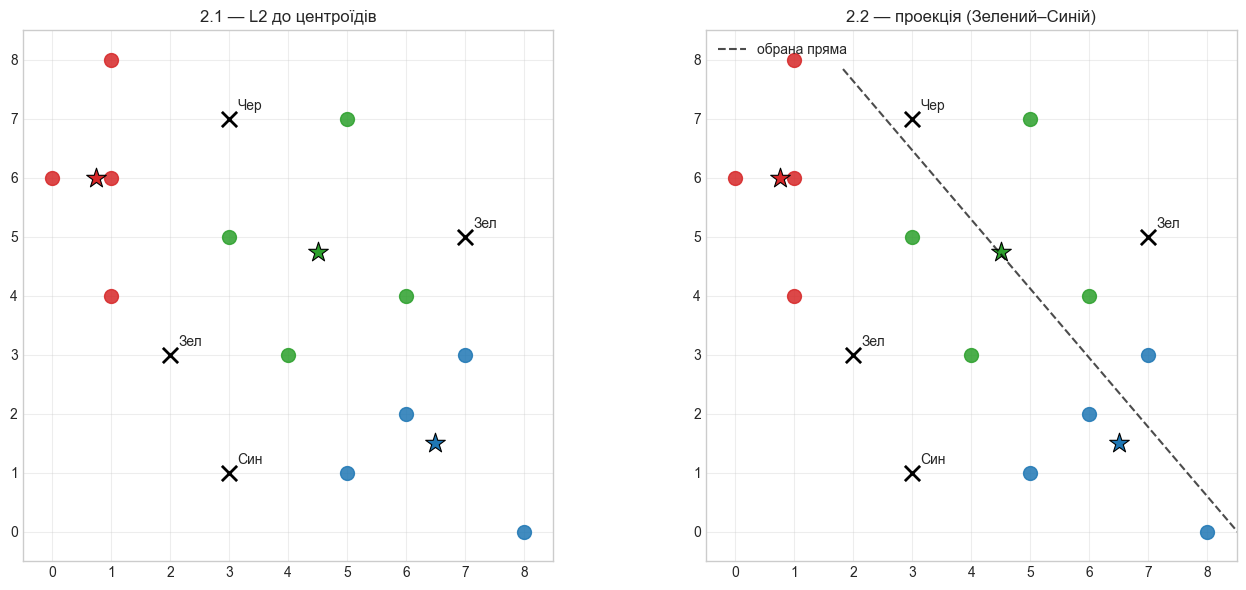

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, title, preds in [
    (axes[0], "2.1 — L2 до центроїдів", preds_21),
    (axes[1], f"2.2 — проекція ({best_name})", preds_22),
]:
    for name in CLASS_NAMES:
        pts = train[name]
        ax.scatter(pts[:, 0], pts[:, 1], c=CLASS_SPECS[name]["color"], s=100, alpha=0.85)
    for name in CLASS_NAMES:
        c = centroids[name]
        ax.scatter(c[0], c[1], c=CLASS_SPECS[name]["color"], s=220, marker="*", edgecolors="k", linewidths=0.8)
    for p, pred in zip(TEST_POINTS, preds):
        ax.scatter(p[0], p[1], c="black", s=120, marker="x", linewidths=2, zorder=5)
        ax.annotate(pred[:3], (p[0], p[1]), textcoords="offset points", xytext=(6, 6), fontsize=10)
    ax.set_xlim(-0.5, 8.5)
    ax.set_ylim(-0.5, 8.5)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.grid(True, alpha=0.35)

# пряма 2.2 на лівому графіку не обов'язкова; на правому — напрямок обраної прямої
o, u = best_line["origin"], best_line["u"]
ts = []
for pts in train.values():
    ts.extend(proj(pts, best_line).tolist())
ts.extend(proj(TEST_POINTS, best_line).tolist())
t0, t1 = min(ts) - 0.5, max(ts) + 0.5
seg = np.column_stack([o + t0 * u, o + t1 * u])
axes[1].plot(seg[:, 0], seg[:, 1], "k--", lw=1.5, alpha=0.7, label="обрана пряма")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

### Рівняння прямих через центроїди (ручний підрахунок)

Центри мас: $\mu_{\text{Ч}}=(\tfrac34;\,6)$, $\mu_{\text{З}}=(\tfrac92;\,\tfrac{19}{4})$, $\mu_{\text{С}}=(\tfrac{13}{2};\,\tfrac32)$.

Пряма через $\mu_a(x_a,y_a)$ та $\mu_b(x_b,y_b)$:

$$k=\frac{y_b-y_a}{x_b-x_a},\qquad y-y_a=k(x-x_a).$$

| Пряма | $k$ | Рівняння $y=f(x)$ | Загальний вигляд $Ax+By+C=0$ |
|-------|-----|-------------------|------------------------------|
| Ч–З | $-\tfrac13$ | $y=6{,}25-\dfrac{x}{3}$ | $x+3y=\dfrac{75}{4}$ |
| Ч–С | $-\dfrac{18}{23}$ | $y=6-\dfrac{18}{23}\!\left(x-\dfrac34\right)$ | $18x+23y=\dfrac{303}{2}$ |
| З–С | $-\dfrac{13}{8}$ | $y=\dfrac{193}{16}-\dfrac{13}{8}x$ | $13x+8y=\dfrac{193}{2}$ |

Усі три прямі **точно** проходять через відповідну пару центроїдів (перевірка підстановкою).

Перевірка: підстановка центроїдів у y = y_a + k(x − x_a)

Червоний–Зелений: k=-0.333333
  μ_Чер: y_факт=6.0, y_формула=6.0000
  μ_Зел: y_факт=4.75, y_формула=4.7500
Червоний–Синій: k=-0.782609
  μ_Чер: y_факт=6.0, y_формула=6.0000
  μ_Син: y_факт=1.5, y_формула=1.5000
Зелений–Синій: k=-1.625000
  μ_Зел: y_факт=4.75, y_формула=4.7500
  μ_Син: y_факт=1.5, y_формула=1.5000


/var/folders/tt/_3ywz8k966s1ps_dnfnpgfy40000gn/T/ipykernel_76013/2841228527.py:75: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()


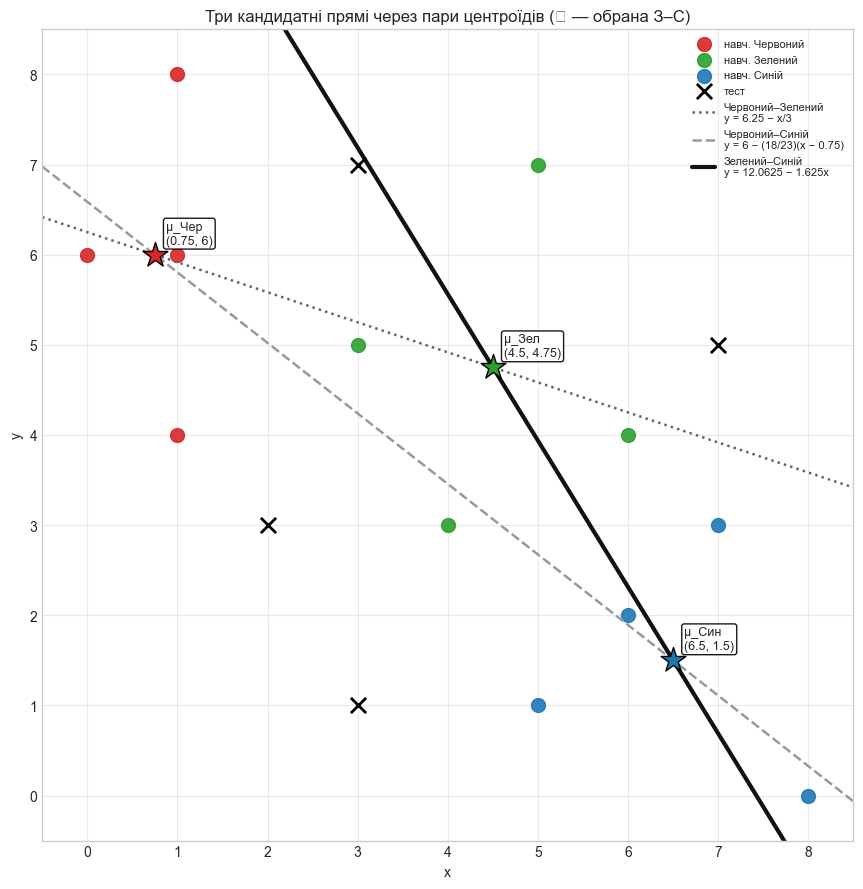

In [11]:
def line_explicit_y(x, k, x0, y0):
    return y0 + k * (x - x0)


LINE_EQS = {
    "Червоний–Зелений": {
        "through": ("Червоний", "Зелений"),
        "k": -1 / 3,
        "form": "y = 6.25 − x/3",
        "implicit": "x + 3y = 18.75",
        "style": ":",
        "color": "#666666",
    },
    "Червоний–Синій": {
        "through": ("Червоний", "Синій"),
        "k": -18 / 23,
        "form": "y = 6 − (18/23)(x − 0.75)",
        "implicit": "18x + 23y = 151.5",
        "style": "--",
        "color": "#999999",
    },
    "Зелений–Синій": {
        "through": ("Зелений", "Синій"),
        "k": -13 / 8,
        "form": "y = 12.0625 − 1.625x",
        "implicit": "13x + 8y = 96.5",
        "style": "-",
        "color": "#111111",
    },
}

print("Перевірка: підстановка центроїдів у y = y_a + k(x − x_a)\n")
for lname, info in LINE_EQS.items():
    a, b = info["through"]
    xa, ya = centroids[a]
    xb, yb = centroids[b]
    k = info["k"]
    y_a_calc = ya + k * (xa - xa)
    y_b_calc = ya + k * (xb - xa)
    print(f"{lname}: k={k:.6f}")
    print(f"  μ_{a[:3]}: y_факт={ya}, y_формула={y_a_calc:.4f}")
    print(f"  μ_{b[:3]}: y_факт={yb}, y_формула={y_b_calc:.4f}")

fig, ax = plt.subplots(figsize=(9, 9))

for name in CLASS_NAMES:
    pts = train[name]
    ax.scatter(pts[:, 0], pts[:, 1], c=CLASS_SPECS[name]["color"], s=100, alpha=0.9, label=f"навч. {name}")
    c = centroids[name]
    ax.scatter(c[0], c[1], c=CLASS_SPECS[name]["color"], s=350, marker="*", edgecolors="black", linewidths=1.0, zorder=6)
    ax.annotate(f"μ_{name[:3]}\n({c[0]:g}, {c[1]:g})", (c[0], c[1]), xytext=(8, 8), textcoords="offset points", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.9))

ax.scatter(TEST_POINTS[:, 0], TEST_POINTS[:, 1], c="black", s=120, marker="x", linewidths=2, label="тест", zorder=5)

x_line = np.linspace(-0.5, 8.5, 200)
for lname, info in LINE_EQS.items():
    a, b = info["through"]
    xa, ya = centroids[a]
    xb, yb = centroids[b]
    k = info["k"]
    y_line = line_explicit_y(x_line, k, xa, ya)
    lw = 3.0 if lname == best_name else 1.8
    ax.plot(x_line, y_line, linestyle=info["style"], color=info["color"], linewidth=lw,
            label=f"{lname}\n{info['form']}")

ax.set_xlim(-0.5, 8.5)
ax.set_ylim(-0.5, 8.5)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Три кандидатні прямі через пари центроїдів (★ — обрана З–С)")
ax.legend(loc="upper right", fontsize=8, framealpha=0.95)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Підсумок

In [12]:
print(f"{'Тестова точка':<14} | {'2.1 (L2)':<12} | {'2.2 (проекція)':<14}")
print("-" * 44)
for p, p1, p2 in zip(TEST_POINTS, preds_21, preds_22):
    print(f"({p[0]:g}, {p[1]:g}){'':<6} | {p1:<12} | {p2:<14}")

Тестова точка  | 2.1 (L2)     | 2.2 (проекція)
--------------------------------------------
(3, 7)       | Червоний     | Червоний      
(7, 5)       | Зелений      | Зелений       
(2, 3)       | Зелений      | Зелений       
(3, 1)       | Синій        | Синій         
